#### Randomized Search  CV

Randomized Search CV refers to the technique of selecting and considering only few random combinations of hyper parameters instead of considering all combinations of hyper parameters.



#### Problem Statement:---

1.  A telecomm company wants to predict whether the customer will churn (leave) or not.

2.  If the output variable is 1 =============>   Customer   leaves the company

    If the output variable is 0 =============>   Customer   stays


#### Dierence between GridSearchCV and RandomizedSearchCV :----

1.  GridSearchCV refers to the technique of going through all the combinations of hyper parameters and finding out the best hyper parameter that can be suitable for a machine learning model.

2.  RandomizedSearchCV refers to the technique of considering only a few random combinations of hyper parameters instead of all combinations of hyper parameters for finding out the optimal solution or a machine learning model.

#### Steps used in the Algorithm:---

#### Step 1: Import  all the necessary libraries

In [1372]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.ensemble        import  RandomForestClassifier
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

#### Step 2: Load the dataset

In [1373]:
#### Load the dataset

df = pd.read_csv("Telecomm_Customer.csv")

In [1374]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### OBSERVATIONS:

1.  The above dataset depicts about the details of all the customers of the Telecomm company.

2.  It even predicts whether the customer will churn or not.

#### Step 3:    Perform the Data Exploration

In [1375]:
#### get the top five rows of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1376]:
#### get the bottom five rows of the dataset

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [1377]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 7043


In [1378]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (7043, 21)


In [1379]:
#### get the columns used in the dataset

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [1380]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [1381]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [1382]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


#### Step 4: Perform Data Cleaning and Feature Engineering

In [1383]:
#### Remove all the unnecessary column "CustomerID" from the dataset

df.drop(columns="customerID",axis=1,inplace=True)

In [1384]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1385]:
from    sklearn.preprocessing  import  LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

In [1386]:
#### Consider all the categorical columns

for x in df.columns:
    #### To filter out all the categorical columns
    if(df[x].dtype == "object"):
        ##### use the label encoder to convert all the categorical values into the numerical ones
        df[x]   =   label.fit_transform(df[x])

In [1387]:
#### Again check the dataset

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


#### OBSERAVTIONS:

1.  All the categorical columns have been converted into the numerical values after performing the label encoding process.

In [1388]:
#### Check the length of the dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 7043


In [1389]:
#### Check the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (7043, 20)


#### OBSERVATIONS:

1.  There were 21 columns in the dataset.

2.  But customerID was an unnecessary column removed from the dataset.

3.  So now the columns were reduced from 21 to 20 features.

In [1390]:
#### Check the data types of the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


#### OBSERVATIONS:

1.  All the columns have their data types in integer or in numeric format.

In [1391]:
#### To check for the NULL records in the dataset

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1392]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,3,45.70,3822,1
1338,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.15,1609,1
1491,0,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,19.55,1485,0
1739,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.90,5454,1
1932,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.20,1610,0
2713,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,1,3,20.45,1615,0
2892,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.45,1615,0
3301,0,1,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.60,5448,1
3754,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,20.05,1607,0
4098,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,1,3,20.20,1610,1


#### OBSERVATIONS:

1.  There were some duplicate records in the dataset. So remove them

In [1393]:
#### drop all the duplicate records in the revised dataset

df.drop_duplicates(inplace=True)

In [1394]:
#### Check the length of the dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 7021


In [1395]:
#### Check the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (7021, 20)


#### OBSERVATIONS:

1.  There were 22 duplicate records in the dataset.

2.  By using the drop duplicates function, those duplicate records were removed from the dataset.

3.  Now the total number of records in the dataset got reduced from 7043 to 7021.

In [1396]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### OBSERVATIONS:

1.  There are no duplicate records in the new revised dataset.

#### Step 5: Perform Exploratory Data Analysis (EDA)

In [1397]:
#### Get the correlation for all the numerical columns used in the dataset

df.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001125,-0.001014,0.011081,0.006185,-0.006769,-0.005939,-0.001762,-0.015262,-0.012182,0.000449,-0.007045,-0.006461,-0.008781,0.000811,-0.011350,0.016304,-0.013158,-0.004341,-0.008763
SeniorCitizen,-0.001125,1.000000,0.015553,-0.212115,0.015349,0.008909,0.145521,-0.031221,-0.128267,-0.013675,-0.021448,-0.151349,0.030704,0.047209,-0.143624,0.156196,-0.037320,0.219434,0.036981,0.151619
Partner,-0.001014,0.015553,1.000000,0.451659,0.377346,0.018728,0.139827,0.003667,0.150589,0.152518,0.165752,0.126422,0.136443,0.128635,0.293042,-0.015776,-0.152069,0.094301,0.059076,-0.149135
Dependents,0.011081,-0.212115,0.451659,1.000000,0.157603,-0.001092,-0.027083,0.046608,0.151984,0.090502,0.080015,0.133303,0.046140,0.020525,0.241912,-0.112220,-0.038185,-0.116191,-0.010039,-0.163459
tenure,0.006185,0.015349,0.377346,0.157603,1.000000,0.009786,0.340458,-0.026847,0.325762,0.370824,0.371062,0.323197,0.288737,0.296225,0.670728,0.005053,-0.367827,0.245251,0.158274,-0.351508
PhoneService,-0.006769,0.008909,0.018728,-0.001092,0.009786,1.000000,-0.019554,0.387549,-0.015026,0.024439,0.004043,-0.018980,0.055807,0.044322,0.003101,0.016824,-0.005304,0.248984,0.083548,0.011323
MultipleLines,-0.005939,0.145521,0.139827,-0.027083,0.340458,-0.019554,1.000000,-0.106819,0.006599,0.116625,0.121633,0.010909,0.174225,0.180113,0.108553,0.164814,-0.174073,0.432246,0.114613,0.040175
InternetService,-0.001762,-0.031221,0.003667,0.046608,-0.026847,0.387549,-0.106819,1.000000,-0.029421,0.035736,0.044563,-0.027019,0.107508,0.098435,0.102456,-0.137056,0.082669,-0.320525,-0.053313,-0.047366
OnlineSecurity,-0.015262,-0.128267,0.150589,0.151984,0.325762,-0.015026,0.006599,-0.029421,1.000000,0.184211,0.175061,0.284255,0.043553,0.054847,0.374556,-0.157024,-0.096968,-0.053347,0.043863,-0.288505
OnlineBackup,-0.012182,-0.013675,0.152518,0.090502,0.370824,0.024439,0.116625,0.035736,0.184211,1.000000,0.186760,0.194841,0.146071,0.135587,0.280658,-0.012565,-0.124724,0.120391,0.092239,-0.194214


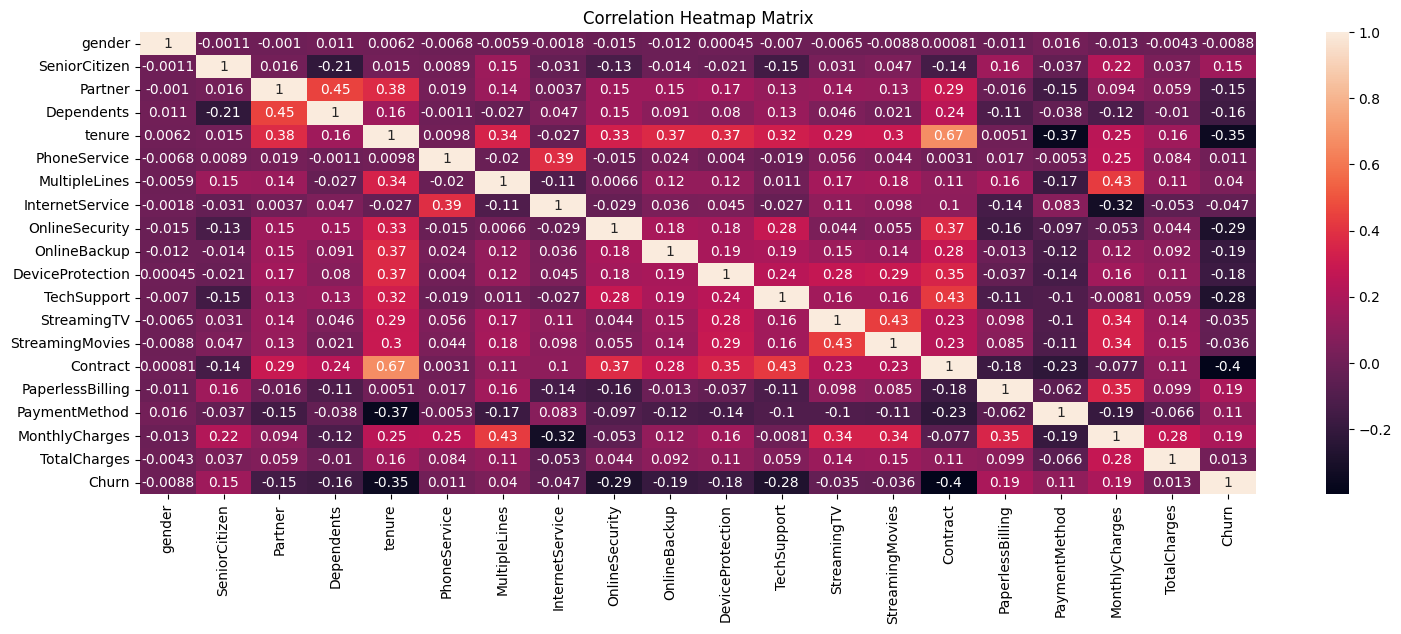

In [1398]:
#### get the graphical representation for the correlation for all the numerical columns used in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above matrix depicts about the correlation between all the numeric columns used in the dataset.

In [1399]:
#### get the categorical counts of the "Churn" category in the dataset

df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

#### OBSERVATIONS:

1.  Out of 7021 records, the total number of customers that will stay is 5164 and the customers that will churn is 1857.

#### Step 6: Divide the dataset into independent and dependent features

In [1400]:
#### independent features

X = df.drop(columns="Churn",axis=1)

In [1401]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


In [1402]:
#### dependent features

Y = df['Churn']

In [1403]:
Y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7021, dtype: int64

#### OBSERVATIONS:

1.  The dataset is divided into input and the output

2.  The input are from gender........ TotalCharges

3.  The output is the Churn

#### Step 7: Divide the independent and dependent features into training and testing data

In [1404]:
from sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1405]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2629,1,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0,1,70.70,731
2650,0,0,0,0,15,1,2,1,2,0,2,0,0,0,0,1,1,84.35,556
1418,1,0,1,1,67,1,2,1,0,2,0,0,0,2,0,1,0,89.55,5138
5774,1,0,0,0,5,1,0,0,0,2,0,2,0,2,0,1,0,65.60,2938
2425,1,0,0,0,26,1,0,2,1,1,1,1,1,1,0,1,2,20.30,4306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6696,1,0,0,0,5,1,2,1,0,2,2,0,0,2,0,0,2,96.55,4237
2094,0,0,0,0,18,1,0,2,1,1,1,1,1,1,0,0,3,19.65,3349
4991,0,0,0,0,58,1,0,1,2,2,2,0,2,2,1,1,2,106.45,5016
6882,0,1,0,0,71,1,2,1,2,2,0,2,2,0,1,1,1,99.65,5617


In [1406]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5627,1,1,1,0,7,1,2,1,0,0,0,0,0,0,0,1,2,74.85,4091
6126,1,1,0,0,19,1,0,1,0,0,2,0,2,2,0,1,1,95.90,1303
2361,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,3,45.95,3826
2201,0,0,0,0,36,1,0,0,2,2,2,2,2,2,1,0,0,85.85,2600
832,0,0,1,1,70,1,0,0,2,2,2,2,0,2,1,0,1,74.10,4374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2310,1,0,0,0,72,0,1,0,2,2,2,2,2,2,2,1,0,63.70,3791
2685,0,0,1,0,72,1,2,1,2,2,2,0,2,0,2,0,0,100.65,5687
1104,1,0,0,0,42,1,0,2,1,1,1,1,1,1,1,1,3,19.55,6168
5704,0,0,1,0,19,1,2,1,0,0,0,0,2,0,0,1,2,86.85,1013


In [1407]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (5616, 19)
Shape of the input testing  data is: (1405, 19)


In [1408]:
Y_train

2629    1
2650    0
1418    0
5774    0
2425    0
       ..
6696    0
2094    0
4991    1
6882    0
400     0
Name: Churn, Length: 5616, dtype: int64

In [1409]:
Y_test

5627    0
6126    1
2361    1
2201    0
832     0
       ..
2310    0
2685    0
1104    0
5704    0
5398    0
Name: Churn, Length: 1405, dtype: int64

In [1410]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (5616,)
Shape of the output testing  data is: (1405,)


#### OBSERVATIONS:

1.  Out of 7021 records,

    (a.)    5616 records are of the training data

    (b.)    1405 records are of the testing data

#### Step 8: Perform Feature Scaling on the inputs

In [1411]:
from  sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [1412]:
X_train_scaled

array([[ 1.00035619, -0.44031529, -0.97363795, ..., -0.53732926,
         0.19316451, -1.34703038],
       [-0.99964394, -0.44031529, -0.97363795, ..., -0.53732926,
         0.64735514, -1.43962533],
       [ 1.00035619, -0.44031529,  1.02707582, ..., -1.4762344 ,
         0.82038014,  0.98477497],
       ...,
       [-0.99964394, -0.44031529, -0.97363795, ...,  0.40157588,
         1.3827114 ,  0.92022307],
       [-0.99964394,  2.2710999 , -0.97363795, ..., -0.53732926,
         1.15644794,  1.23822058],
       [-0.99964394, -0.44031529, -0.97363795, ..., -1.4762344 ,
        -1.50214778,  0.94456231]])

In [1413]:
X_test_scaled

array([[ 1.00035619,  2.2710999 ,  1.02707582, ...,  0.40157588,
         0.33125177,  0.43079263],
       [ 1.00035619,  2.2710999 , -0.97363795, ..., -0.53732926,
         1.03167029, -1.04437718],
       [-0.99964394, -0.44031529, -0.97363795, ...,  1.34048102,
        -0.63036796,  0.29057742],
       ...,
       [ 1.00035619, -0.44031529, -0.97363795, ...,  1.34048102,
        -1.50880259,  1.52976238],
       [-0.99964394, -0.44031529,  1.02707582, ...,  0.40157588,
         0.73054024, -1.19782024],
       [ 1.00035619, -0.44031529, -0.97363795, ...,  1.34048102,
        -1.50214778,  0.03289891]])

#### Step 8: Build the Random Forest Classifier model

In [1414]:
#### create an object for Random Forest Classifier model

rfc = RandomForestClassifier(
    random_state=42
)

#### Step 9: Define the object for RandomizedSerachCV object

In [1415]:
#### define the param grid

param_grid = {
    "n_estimators"      :       [50,    100,    200,    300,    500]            ,
    "max_depth"         :       [None,  5,  10, 20, 30]                         ,
    "min_samples_split" :       [2,5,10]                                        ,
    "min_samples_leaf"  :       [1,2,4]                                         ,
    "criterion"         :       ["gini","entropy"]                              ,
    "bootstrap"         :       [True,False]    
}

In [1416]:
#### define the cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [1417]:
#### define the object for RandomizedSearchCV Object

ran_obj = RandomizedSearchCV(
    estimator                   =           rfc                 ,
    param_distributions         =           param_grid          ,
    cv                          =            cv                 ,
    n_iter                      =            20                 ,
    verbose                     =            2                  ,
    scoring                     =           'accuracy'          ,
    random_state                =            42                 ,
    n_jobs                      =             -1
)

#### OBSERVATIONS:

1.  The object for Randomized Search CV has been created with the help of the following parameters:---

    (a.)   estimator   ====================>   base model

    (b.)   param_distributions  ===========>   list of the parameters to be defined

    (c.)   cv             =================>   perform cross validation to improve the accuracy

    (d.)   n_iter       ===================>   Number of iterations needed to train the model

    (e.)   verbose     =====================>  printing the output training frequency

    (f.)   scoring    ======================>   depict the scoring measurement of the model

    (g.)   random_state =====================>  It ensures reproducibility

In [1418]:
#### using the object of RandomizedSearchCV Object, train the model

ran_obj.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 5, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300,
                                                         500]},
                   random_state=42, scoring='accuracy', verbose=2)

#### OBSERVATIONS:

1.  The model is trained using the object of Random Forest Classifier and even with the help of RandomizedSearchCV

    (a.)    where it tries all the random hyper parameter combinations

    (b.)   finds out the best parameters and the estimator for the model

In [1419]:
#### Obtain the best parameter and the estimator for the model

best_parameter = ran_obj.best_params_

print("Best Parameter for the model is:", best_parameter)


best_estimator = ran_obj.best_estimator_

print("Best Estimator for the model is:", best_estimator)

Best Parameter for the model is: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None, 'criterion': 'gini', 'bootstrap': True}
Best Estimator for the model is: RandomForestClassifier(min_samples_leaf=4, min_samples_split=5,
                       n_estimators=500, random_state=42)


In [1420]:
#### Obtain the best score for the model

best_score = ran_obj.best_score_

print("Best Score for the model is:", best_score)

Best Score for the model is: 0.8046618266400053


In [1421]:
#### Predict the model

Y_pred_rangrid = best_estimator.predict(X_test_scaled)

In [1422]:
Y_pred_rangrid

array([1, 0, 1, ..., 0, 1, 0])

===============================Accuracy score=======================================================
Accuracy score of the model is: 78.86120996441281
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[930 103]
 [194 178]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.70      1405
weighted avg       0.78      0.79      0.78      1405



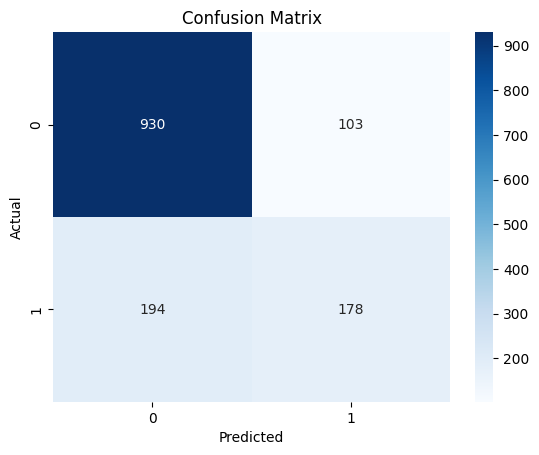

===============================Precision Score=======================================================
Precision score of the model is: 0.6334519572953736
===============================Recall Score=======================================================
Recall score of the model is: 0.478494623655914
===============================F1 Score=======================================================
F1 score of the model is: 0.5451761102603369


In [1423]:
#### Evaluate the Classification Metrics after performing RandomizedSearchCV

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_rangrid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_rangrid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_rangrid)

print("Classification report of the model is:", crgrid)


sns.heatmap(cmgrid, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_rangrid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_rangrid)

print("Recall score of the model is:", regrid)


print("===============================F1 Score=======================================================")

f1grid = f1_score(Y_test, Y_pred_rangrid)

print("F1 score of the model is:", f1grid)

#### OBSERVATIONS:

1.  The accuracy o the Random Forest Classifier model for Telocomm Customer dataset using RandomizedSerachCV is 78.86 which is very high.

2.  So here the model is working fine.

In [1424]:
#### Calculate the roc auc score

Y_pred_proba = best_estimator.predict_proba(X_test)[:,1]


rocaucscore = roc_auc_score(Y_test, Y_pred_proba)

print("ROC AUC Score of the model is:", rocaucscore)

ROC AUC Score of the model is: 0.7178928686673121


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


#### OBSERVATIONS:

1.  The ROC AUC Score is a single numerical value that explains how well the model seperates between the datas of Class 0 and Class 1 

2.  It easily seperates the datas of two different categories.

3.  This model with the ROC AUC Score of 0.717 explains that the model has 71.7 % of the ability to determine correctly whether the customer will churn or not.

False Positive Rate is: [0.00000000e+00 9.68054211e-04 1.93610842e-03 1.93610842e-03
 3.87221684e-03 3.87221684e-03 5.80832527e-03 5.80832527e-03
 1.06485963e-02 1.06485963e-02 1.16166505e-02 1.16166505e-02
 1.25847047e-02 1.25847047e-02 1.35527590e-02 1.35527590e-02
 1.45208132e-02 1.64569216e-02 1.74249758e-02 1.74249758e-02
 1.93610842e-02 1.93610842e-02 2.03291384e-02 2.03291384e-02
 2.12971926e-02 2.32333011e-02 3.09777348e-02 3.19457890e-02
 3.29138432e-02 3.29138432e-02 3.58180058e-02 3.58180058e-02
 3.77541142e-02 3.77541142e-02 4.06582769e-02 4.35624395e-02
 4.54985479e-02 4.64666021e-02 4.74346563e-02 4.84027106e-02
 4.84027106e-02 5.32429816e-02 5.42110358e-02 5.42110358e-02
 6.87318490e-02 7.06679574e-02 7.35721200e-02 7.45401742e-02
 7.45401742e-02 7.55082285e-02 7.74443369e-02 7.74443369e-02
 7.84123911e-02 7.84123911e-02 7.93804453e-02 7.93804453e-02
 8.22846079e-02 8.51887706e-02 8.71248790e-02 8.80929332e-02
 8.80929332e-02 8.90609874e-02 8.90609874e-02 9.09970958e-02


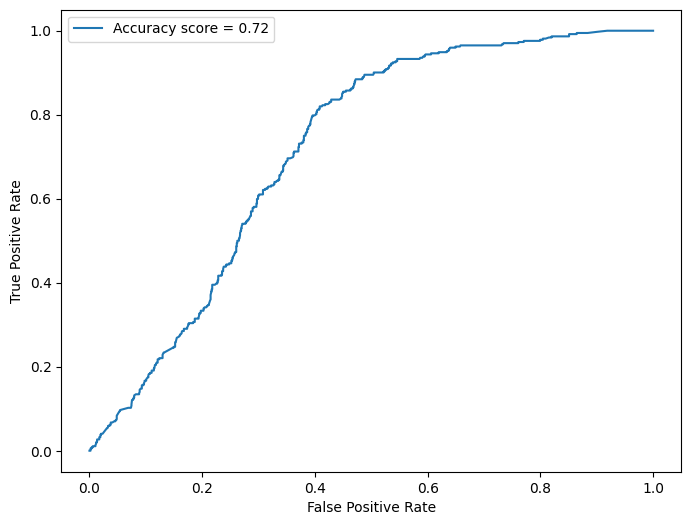

In [1425]:
#### Caluclate the ROC AUC Curve

fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)

print("False Positive Rate is:", fpr)

print("True Positive Rate is:", tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"Accuracy score = {rocaucscore:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### OBSERVATIONS:

1.  The above graph is a ROC Curve (Receiver Operating Characteristics) Curve.

2.  This graph explains  the relationship between the False Positive Rate vs True Positive Rate.

#### Step 10: Predict whether the customer will churn or not based on the sample data

In [1426]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1597
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,5698
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,2994
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,2660


In [1427]:
X.iloc[[35]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
35,0,0,1,1,72,1,2,1,2,2,0,2,2,0,2,0,0,99.9,5644


In [1428]:
df.iloc[[35]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
35,0,0,1,1,72,1,2,1,2,2,0,2,2,0,2,0,0,99.9,5644,0


In [1429]:
#### define the sample data

sample = X.iloc[[35]]

print("Sample Data is:")
print(sample)

#### perform prediction

prediction = best_estimator.predict(sample)

print("Prediction is:", prediction)

#### probability prediction

prediction_probability = best_estimator.predict_proba(sample)

print("Prediction Probability is:")
print(prediction_probability)

#### final result

if prediction[0] == 1:
    print("Customer will churn")
else:
    print("Customer will stay")

Sample Data is:
    gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
35       0              0        1           1      72             1   

    MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
35              2                1               2             2   

    DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
35                 0            2            2                0         2   

    PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  
35                 0              0            99.9          5644  
Prediction is: [0]
Prediction Probability is:
[[0.95305111 0.04694889]]
Customer will stay


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
